In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage,dendrogram
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [8]:
milk = pd.read_csv('milk.csv',index_col=0)
milk

,water,protein,fat,lactose,ash
Animal,,,,,
HORSE,90.1,2.6,1.0,6.9,0.35
ORANGUTAN,88.5,1.4,3.5,6.0,0.24
MONKEY,88.4,2.2,2.7,6.4,0.18
DONKEY,90.3,1.7,1.4,6.2,0.40
HIPPO,90.4,0.6,4.5,4.4,0.10
CAMEL,87.7,3.5,3.4,4.8,0.71
BISON,86.9,4.8,1.7,5.7,0.90
BUFFALO,82.1,5.9,7.9,4.7,0.78
GUINEA PIG,81.9,7.4,7.2,2.7,0.85


In [17]:
ss = StandardScaler().set_output(transform='pandas')
X  =  milk.copy()
X_scaled = ss.fit_transform(X)

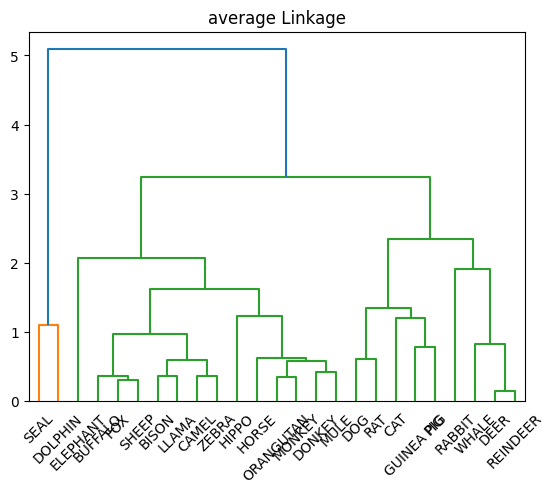

In [24]:
link='average'
mergings = linkage(X_scaled,method=link)
dendrogram(mergings,labels=list(X_scaled.index))
plt.title(link+" Linkage")
plt.show()

In [22]:
scores = []
no_of_clusters = np.arange(2,6)
for n in no_of_clusters:
    agg = AgglomerativeClustering(n_clusters=n)
    agg.fit(X_scaled)
    score = silhouette_score(X_scaled,agg.labels_)
    scores.append([n,score])
df_scores = pd.DataFrame(scores,columns=['No. of Clusters','Silhouette Score'])    
df_scores.sort_values('Silhouette Score',ascending=False)

,No. of Clusters,Silhouette Score
1,3,0.539160
0,2,0.525851
2,4,0.443481
3,5,0.398301


In [28]:
scores = []
no_of_clusters = [2,3,4,5,6,7]

for n in no_of_clusters:
    clust = KMeans(n_clusters = n, random_state = 26)
    clust.fit(X_scaled)
    score = silhouette_score(X_scaled, clust.labels_)
    scores.append([n, score])
    
df_scores = pd.DataFrame(scores, columns = ["Number of Clusters", "Silhouette Score"])
df_scores.sort_values('Silhouette Score', ascending = False)

/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' 

,Number of Clusters,Silhouette Score
1,3,0.539160
0,2,0.525851
2,4,0.446073
3,5,0.409260
4,6,0.400535
5,7,0.391789


In [41]:
prcomp = PCA().set_output(transform = 'pandas')
milk_scaled = ss.fit_transform(milk)
pca_data = prcomp.fit_transform(milk_scaled)
km = KMeans(n_clusters = 2, random_state = 26)
km.fit(milk_scaled)
pca_data['Cluster'] = km.labels_
# pca_data['Cluster'] = pca_data['Cluster'].astype(str)
pca_data.columns

/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Index(['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'Cluster'], dtype='object')

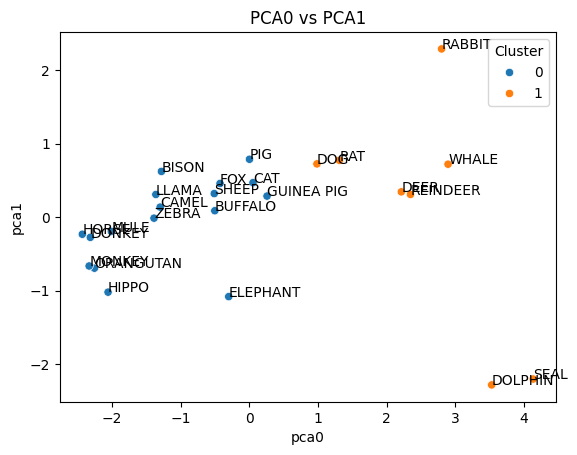

In [43]:
sns.scatterplot(data = pca_data, x = 'pca0', y = 'pca1', hue = 'Cluster')

for i in np.arange(0, milk.shape[0]):
    plt.text(x = pca_data.values[i, 0],
            y = pca_data.values[i, 1],
            s = list(milk.index)[i])
plt.title('PCA0 vs PCA1')
plt.show()

In [45]:
nutrient = pd.read_csv('nutrient.csv',index_col=0)
nutrient

,energy,protein,fat,calcium,iron
Food_Item,,,,,
BEEF BRAISED,340,20,28,9,2.6
HAMBURGER,245,21,17,9,2.7
BEEF ROAST,420,15,39,7,2.0
BEEF STEAK,375,19,32,9,2.6
BEEF CANNED,180,22,10,17,3.7
CHICKEN BROILED,115,20,3,8,1.4
CHICKEN CANNED,170,25,7,12,1.5
BEEF HEART,160,26,5,14,5.9
LAMB LEG ROAST,265,20,20,9,2.6


In [47]:
nutrient_scaled = ss.fit_transform(nutrient)
nutrient_pca = prcomp.fit_transform(nutrient_scaled)

In [50]:
scores = []
n = [2,4,5,7,10]
for i in n:
    kmeans = KMeans(n_clusters=i,random_state=26)
    kmeans.fit(nutrient_scaled)
    score = silhouette_score(nutrient_scaled,kmeans.labels_)
    scores.append([i,score])

    
df_scores = pd.DataFrame(scores,columns=['No. of Clusters','Silhouette Score'])
df_scores.sort_values('Silhouette Score',ascending=False)
    

/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' 

,No. of Clusters,Silhouette Score
2,5,0.394183
1,4,0.387323
3,7,0.375628
4,10,0.366576
0,2,0.325778


In [53]:
kmeans = KMeans(n_clusters=5,random_state=26)
kmeans.fit(nutrient_scaled)
nutrient_pca['Cluster'] = kmeans.labels_
nutrient_pca['Cluster'] = nutrient_pca['Cluster'].astype(str)

/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


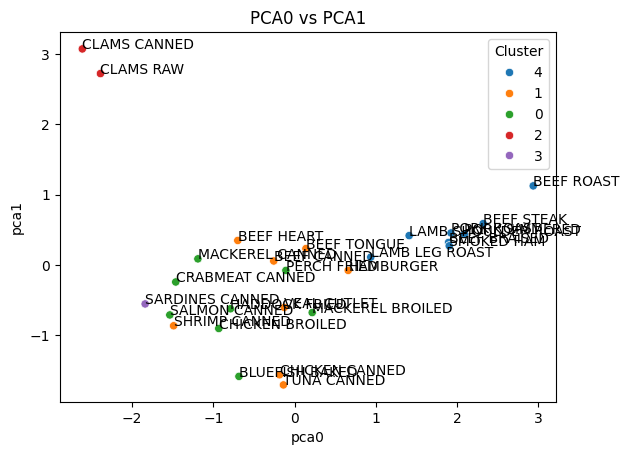

In [54]:
sns.scatterplot(data = nutrient_pca, x = 'pca0', y = 'pca1', hue = 'Cluster')

for i in np.arange(0, nutrient.shape[0]):
    plt.text(x = nutrient_pca.values[i, 0],
            y = nutrient_pca.values[i, 1],
            s = list(nutrient.index)[i])
plt.title('PCA0 vs PCA1')
plt.show()

### Analyzing Centroids/Cluster Analysis 

In [59]:
df = nutrient.copy()
km = KMeans(n_clusters=5,random_state=26)
km.fit(nutrient_scaled)
df['Cluster'] = km.labels_
df.groupby('Cluster').mean().sort_values('Cluster',ascending=False)

/home/pgcp-ai/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,energy,protein,fat,calcium,iron
Cluster,,,,,
4,341.875,18.750,28.875,8.750,2.4375
3,180.000,22.000,9.000,367.000,2.5000
2,57.500,9.000,1.000,78.000,5.7000
1,178.125,22.875,8.750,21.625,2.8500
0,143.125,17.500,6.500,52.625,1.0125
